# Avance 2 — Bull Call Spread sobre SPY
## Simulación de Procesos Financieros — Proyecto Final
**Sara Hernández & Edgardo González** | Abril 2026

---
**Estrategia:** Bull Call Spread  
**Activo subyacente:** SPDR S&P 500 ETF Trust (SPY)  
**Objetivo:** Calcular precios teóricos con Black-Scholes y modelar escenarios con Monte Carlo



In [17]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)  


plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})



## Parámetros del modelo

| Parámetro | Símbolo | Valor | Fuente |
|-----------|---------|-------|--------|
| Precio actual SPY | S₀ | \$710 | Yahoo Finance (abril 2026) |
| Strike call comprada (ATM) | K₁ | \$710 | Estructura Bull Call Spread |
| Strike call vendida (OTM) | K₂ | \$730 | Estructura Bull Call Spread |
| Tasa libre de riesgo | r | 4.25% | T-Bill 1 año (Fed Reserve, abril 2026) |
| Volatilidad histórica SPY | σ | 17.5% | Volatilidad histórica 30d |
| Tiempo al vencimiento | T | 30/365 | 30 días calendario |

In [18]:
# Parámetros del modelo
S0    = 710.0      # Precio actual SPY
K1    = 710.0      # Strike call comprada (ATM)
K2    = 730.0      # Strike call vendida  (OTM)
r     = 0.0425     # Tasa libre de riesgo anual
sigma = 0.175      # Volatilidad anualizada
T     = 30 / 365   # Tiempo al vencimiento en años
M     = 100_000    # Número de simulaciones Monte Carlo

print(f"Parámetros configurados:")
print(f"  S0 = ${S0}   K1 = ${K1}   K2 = ${K2}")
print(f"  r  = {r*100:.2f}%    sigma = {sigma*100:.1f}%   T = {T*365:.0f} días")
print(f"  Simulaciones Monte Carlo: {M:,}")

Parámetros configurados:
  S0 = $710.0   K1 = $710.0   K2 = $730.0
  r  = 4.25%    sigma = 17.5%   T = 30 días
  Simulaciones Monte Carlo: 100,000


## Implementacion Black-Scholes

In [19]:
def bs_call(S, K, r, sigma, T):
    """Precio Black-Scholes de una opción call europea."""
    if T <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_delta(S, K, r, sigma, T):
    """Delta: sensibilidad al precio del subyacente."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def bs_gamma(S, K, r, sigma, T):
    """Gamma: tasa de cambio de Delta."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_theta(S, K, r, sigma, T):
    """Theta: decaimiento temporal diario."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
            - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365

def bs_vega(S, K, r, sigma, T):
    """Vega: sensibilidad a la volatilidad (por +1% de sigma)."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T) / 100

def bs_rho(S, K, r, sigma, T):
    """Rho: sensibilidad a la tasa de interés (por +1%)."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * T * np.exp(-r * T) * norm.cdf(d2) / 100



## Precios teóricos Black-Scholes y estructura de la estrategia

In [20]:
# Precio de cada leg
c1 = bs_call(S0, K1, r, sigma, T)
c2 = bs_call(S0, K2, r, sigma, T)

# Métricas del spread
net_premium = c1 - c2
max_profit  = (K2 - K1) - net_premium
breakeven   = K1 + net_premium
max_loss    = net_premium


print("  BULL CALL SPREAD — PRECIOS BLACK-SCHOLES")

print(f"  Long  Call  K1=${K1}   Prima pagada:    ${c1:.4f}")
print(f"  Short Call  K2=${K2}   Prima recibida:  ${c2:.4f}")

print(f"  Prima neta (débito):   ${net_premium:.4f}")
print(f"  Ganancia máxima:       ${max_profit:.4f}")
print(f"  Pérdida máxima:        ${max_loss:.4f}")
print(f"  Punto de equilibrio:   ${breakeven:.4f}")
print(f"  Ratio R/R:             {max_profit/max_loss:.2f}x")


  BULL CALL SPREAD — PRECIOS BLACK-SCHOLES
  Long  Call  K1=$710.0   Prima pagada:    $15.4569
  Short Call  K2=$730.0   Prima recibida:  $7.3095
  Prima neta (débito):   $8.1474
  Ganancia máxima:       $11.8526
  Pérdida máxima:        $8.1474
  Punto de equilibrio:   $718.1474
  Ratio R/R:             1.45x


## Gráfica 1: Perfil de P&L al vencimiento

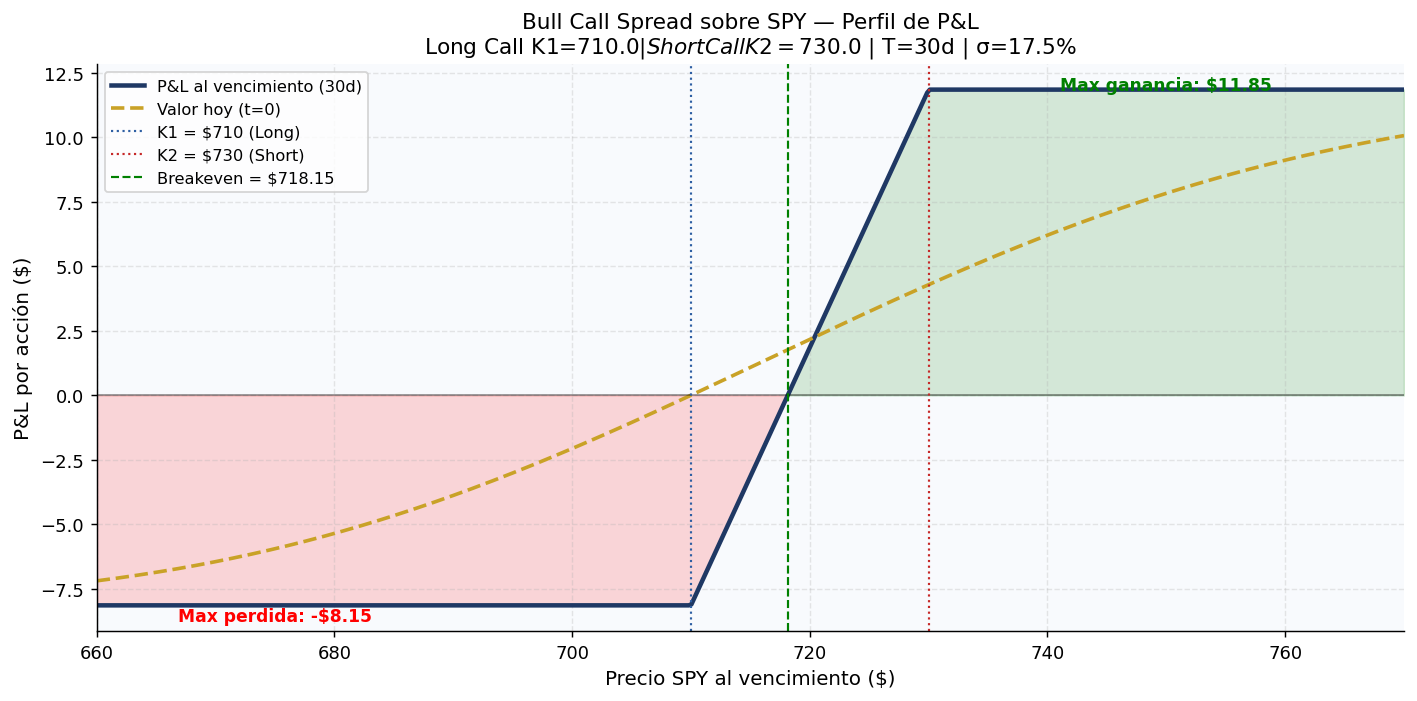

In [ ]:
St = np.linspace(660, 770, 500)
payoff_exp = np.maximum(St - K1, 0) - np.maximum(St - K2, 0) - net_premium
pnl_today  = np.array([bs_call(s, K1, r, sigma, T) - bs_call(s, K2, r, sigma, T) - net_premium
                        for s in St])

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.set_facecolor('#F8FAFD')

ax.plot(St, payoff_exp, color='#1F3864', lw=2.5, label='P&L al vencimiento (30d)')
ax.plot(St, pnl_today,  color="#CAA221", lw=2,   linestyle='--', label='Valor hoy (t=0)')
ax.fill_between(St, payoff_exp, 0, where=(payoff_exp > 0), alpha=0.15, color='green')
ax.fill_between(St, payoff_exp, 0, where=(payoff_exp < 0), alpha=0.15, color='red')
ax.axhline(0,         color='black',   lw=1,   alpha=0.4)
ax.axvline(K1,        color='#2E5FA3', lw=1.2, linestyle=':', label=f'K1 = ${K1:.0f} (Long)')
ax.axvline(K2,        color='#C62828', lw=1.2, linestyle=':', label=f'K2 = ${K2:.0f} (Short)')
ax.axvline(breakeven, color='green',   lw=1.2, linestyle='--', label=f'Breakeven = ${breakeven:.2f}')

ax.annotate(f'Max ganancia: ${max_profit:.2f}', xy=(750, max_profit),
            fontsize=9.5, color='green', fontweight='bold', ha='center')
ax.annotate(f'Max perdida: -${max_loss:.2f}', xy=(675, -max_loss - 0.6),
            fontsize=9.5, color='red', fontweight='bold', ha='center')

ax.set_xlabel('Precio SPY al vencimiento ($)', fontsize=11)
ax.set_ylabel('P&L por acción ($)', fontsize=11)
ax.set_title('Bull Call Spread sobre SPY — Perfil de P&L\n'
             f'Long Call K1=${K1} | Short Call K2=${K2} | T=30d | σ={sigma*100:.1f}%', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(660, 770)
plt.tight_layout()
plt.show()

## Análisis de Griegas del spread

In [8]:
# Griegas del spread en S0
delta_spread = bs_delta(S0,K1,r,sigma,T) - bs_delta(S0,K2,r,sigma,T)
gamma_spread = bs_gamma(S0,K1,r,sigma,T) - bs_gamma(S0,K2,r,sigma,T)
theta_spread = bs_theta(S0,K1,r,sigma,T) - bs_theta(S0,K2,r,sigma,T)
vega_spread  = bs_vega(S0,K1,r,sigma,T)  - bs_vega(S0,K2,r,sigma,T)
rho_spread   = bs_rho(S0,K1,r,sigma,T)   - bs_rho(S0,K2,r,sigma,T)

# Tabla de griegas
greeks_data = {
    'Griega':         ['Delta (Δ)', 'Gamma (Γ)', 'Theta (θ)', 'Vega (V)', 'Rho (ρ)'],
    'Long Call K1':   [f"{bs_delta(S0,K1,r,sigma,T):.4f}",
                       f"{bs_gamma(S0,K1,r,sigma,T):.6f}",
                       f"{bs_theta(S0,K1,r,sigma,T):.4f}",
                       f"{bs_vega(S0,K1,r,sigma,T):.4f}",
                       f"{bs_rho(S0,K1,r,sigma,T):.4f}"],
    'Short Call K2':  [f"{-bs_delta(S0,K2,r,sigma,T):.4f}",
                       f"{-bs_gamma(S0,K2,r,sigma,T):.6f}",
                       f"{-bs_theta(S0,K2,r,sigma,T):.4f}",
                       f"{-bs_vega(S0,K2,r,sigma,T):.4f}",
                       f"{-bs_rho(S0,K2,r,sigma,T):.4f}"],
    'Spread (Neto)':  [f"{delta_spread:.4f}",
                       f"{gamma_spread:.6f}",
                       f"{theta_spread:.4f}",
                       f"{vega_spread:.4f}",
                       f"{rho_spread:.4f}"],
    'Interpretación': [
        f'+${delta_spread:.4f} por cada $1 que suba SPY',
        'Convexidad neta positiva (curvatura)',
        f'Pierde ${abs(theta_spread):.4f}/día por paso del tiempo',
        f'+${vega_spread:.4f} por cada +1% en vol',
        f'+${rho_spread:.4f} por cada +1% en tasa'
    ]
}

df_greeks = pd.DataFrame(greeks_data)
print(df_greeks.to_string(index=False))

   Griega Long Call K1 Short Call K2 Spread (Neto)                         Interpretación
Delta (Δ)       0.5377       -0.3231        0.2146      +$0.2146 por cada $1 que suba SPY
Gamma (Γ)     0.011149     -0.010080      0.001070   Convexidad neta positiva (curvatura)
Theta (θ)      -0.2784        0.2390       -0.0394 Pierde $0.0394/día por paso del tiempo
 Vega (V)       0.8084       -0.7309        0.0776           +$0.0776 por cada +1% en vol
  Rho (ρ)       0.3011       -0.1826        0.1185          +$0.1185 por cada +1% en tasa


## Gráfica 2: Griegas vs. precio de SPY

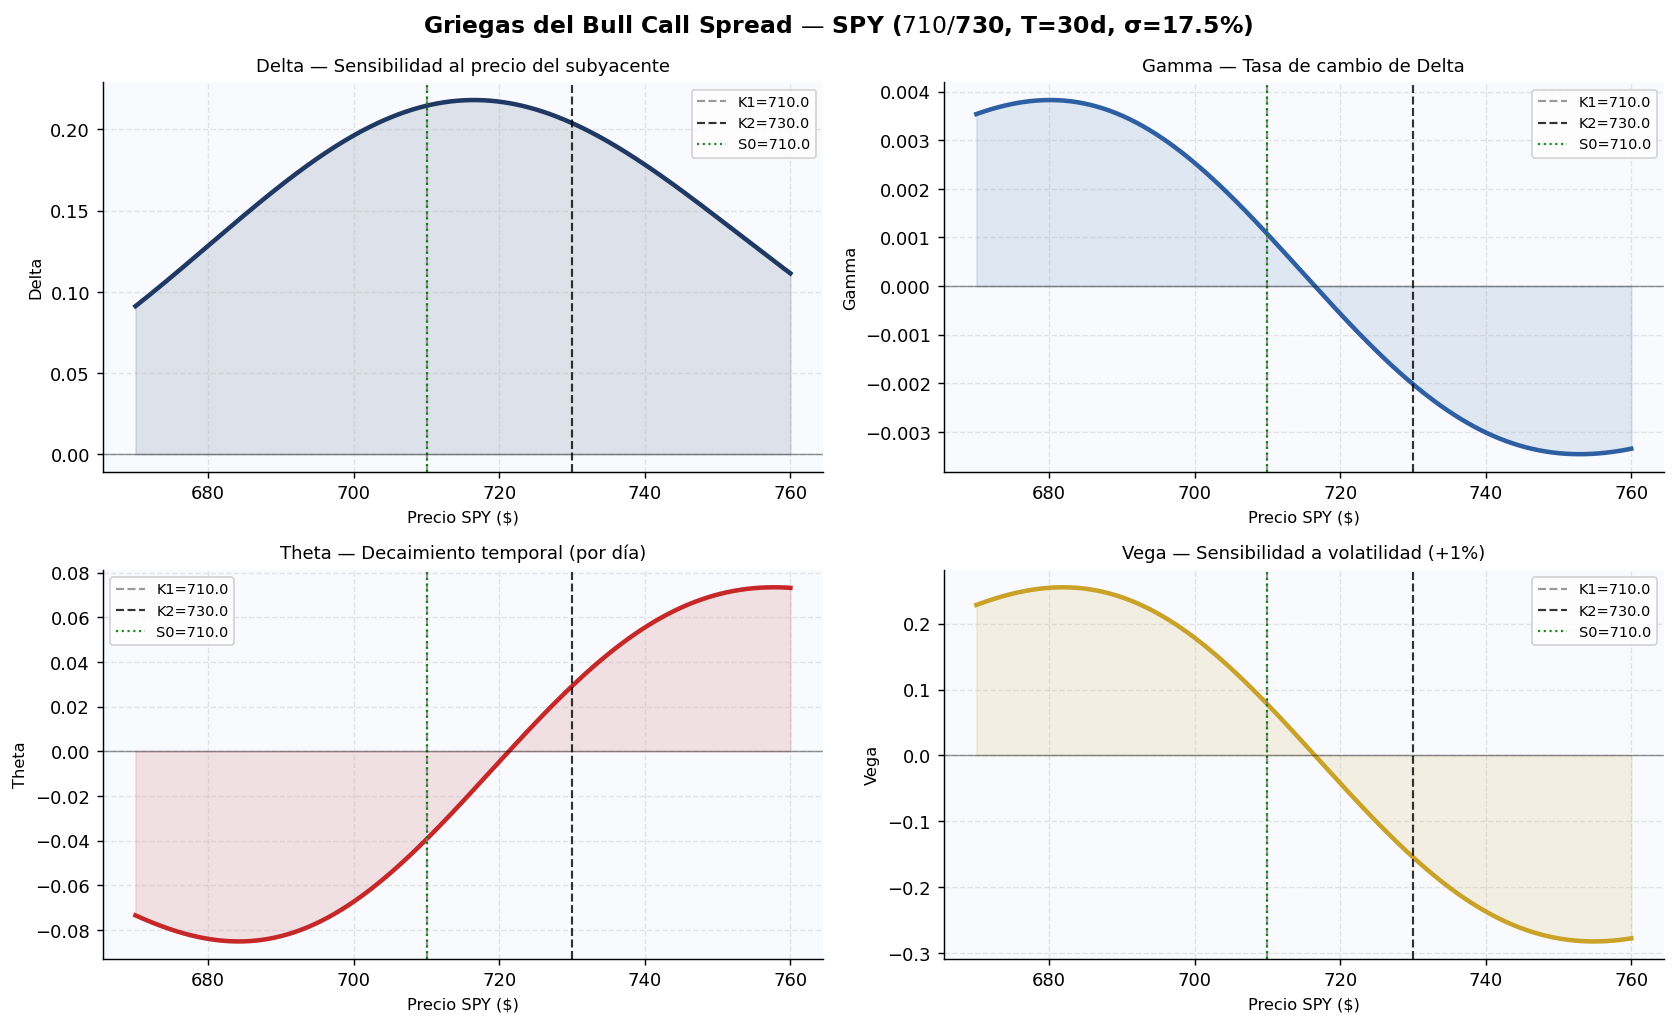

In [9]:
Sv = np.linspace(670, 760, 300)

d_arr  = np.array([bs_delta(s,K1,r,sigma,T)-bs_delta(s,K2,r,sigma,T) for s in Sv])
g_arr  = np.array([bs_gamma(s,K1,r,sigma,T)-bs_gamma(s,K2,r,sigma,T) for s in Sv])
th_arr = np.array([bs_theta(s,K1,r,sigma,T)-bs_theta(s,K2,r,sigma,T) for s in Sv])
ve_arr = np.array([bs_vega(s,K1,r,sigma,T) -bs_vega(s,K2,r,sigma,T)  for s in Sv])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Griegas del Bull Call Spread — SPY ($710/$730, T=30d, σ=17.5%)',
             fontsize=13, fontweight='bold')

configs = [
    (axes[0,0], d_arr,  'Delta',  '#1F3864', 'Sensibilidad al precio del subyacente'),
    (axes[0,1], g_arr,  'Gamma',  '#2E5FA3', 'Tasa de cambio de Delta'),
    (axes[1,0], th_arr, 'Theta',  '#C62828', 'Decaimiento temporal (por día)'),
    (axes[1,1], ve_arr, 'Vega',   '#C9A227', 'Sensibilidad a volatilidad (+1%)'),
]

for ax, arr, name, col, subtitle in configs:
    ax.set_facecolor('#F8FAFD')
    ax.plot(Sv, arr, color=col, lw=2.5)
    ax.fill_between(Sv, arr, 0, alpha=0.12, color=col)
    ax.axvline(K1, color='gray',    lw=1.2, linestyle='--', alpha=0.8, label=f'K1={K1}')
    ax.axvline(K2, color='black',   lw=1.2, linestyle='--', alpha=0.8, label=f'K2={K2}')
    ax.axvline(S0, color='green',   lw=1.2, linestyle=':',  alpha=0.9, label=f'S0={S0}')
    ax.axhline(0,  color='black',   lw=0.8, alpha=0.4)
    ax.set_title(f'{name} — {subtitle}', fontsize=10)
    ax.set_xlabel('Precio SPY ($)', fontsize=9)
    ax.set_ylabel(name, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## Simulación Monte Carlo

In [12]:
# Simulación GBM (Geometric Brownian Motion)

Z     = np.random.standard_normal(M)
ST_mc = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# Payoff del spread para cada escenario
payoff_mc = (np.maximum(ST_mc - K1, 0)
           - np.maximum(ST_mc - K2, 0)
           - net_premium)

# Métricas estadísticas
prob_profit  = (payoff_mc > 0).mean()
prob_max     = (ST_mc > K2).mean()
prob_loss    = (ST_mc < K1).mean()
expected_pnl = payoff_mc.mean()
std_pnl      = payoff_mc.std()
pv_mc        = np.exp(-r * T) * expected_pnl + net_premium  # precio implícito MC


print("  RESULTADOS MONTE CARLO ({:,} simulaciones)".format(M))

print(f"  P(ganancia máxima) — ST > ${K2}:  {prob_max*100:.1f}%")
print(f"  P(ganancia parcial) — ${K1}<ST<${K2}: {(prob_profit-prob_max)*100:.1f}%")
print(f"  P(pérdida máxima) — ST < ${K1}:   {prob_loss*100:.1f}%")

print(f"  E[P&L] esperado:    ${expected_pnl:.4f}")
print(f"  Desv. estándar:     ${std_pnl:.4f}")
print(f"  Precio MC implícito: ${pv_mc:.4f}")
print(f"  Precio BS (teórico): ${net_premium:.4f}")


  RESULTADOS MONTE CARLO (100,000 simulaciones)
  P(ganancia máxima) — ST > $730.0:  30.5%
  P(ganancia parcial) — $710.0<ST<$730.0: 12.2%
  P(pérdida máxima) — ST < $710.0:   48.4%
  E[P&L] esperado:    $0.0235
  Desv. estándar:     $9.0826
  Precio MC implícito: $8.1708
  Precio BS (teórico): $8.1474


## Gráfica 3: Distribución Monte Carlo

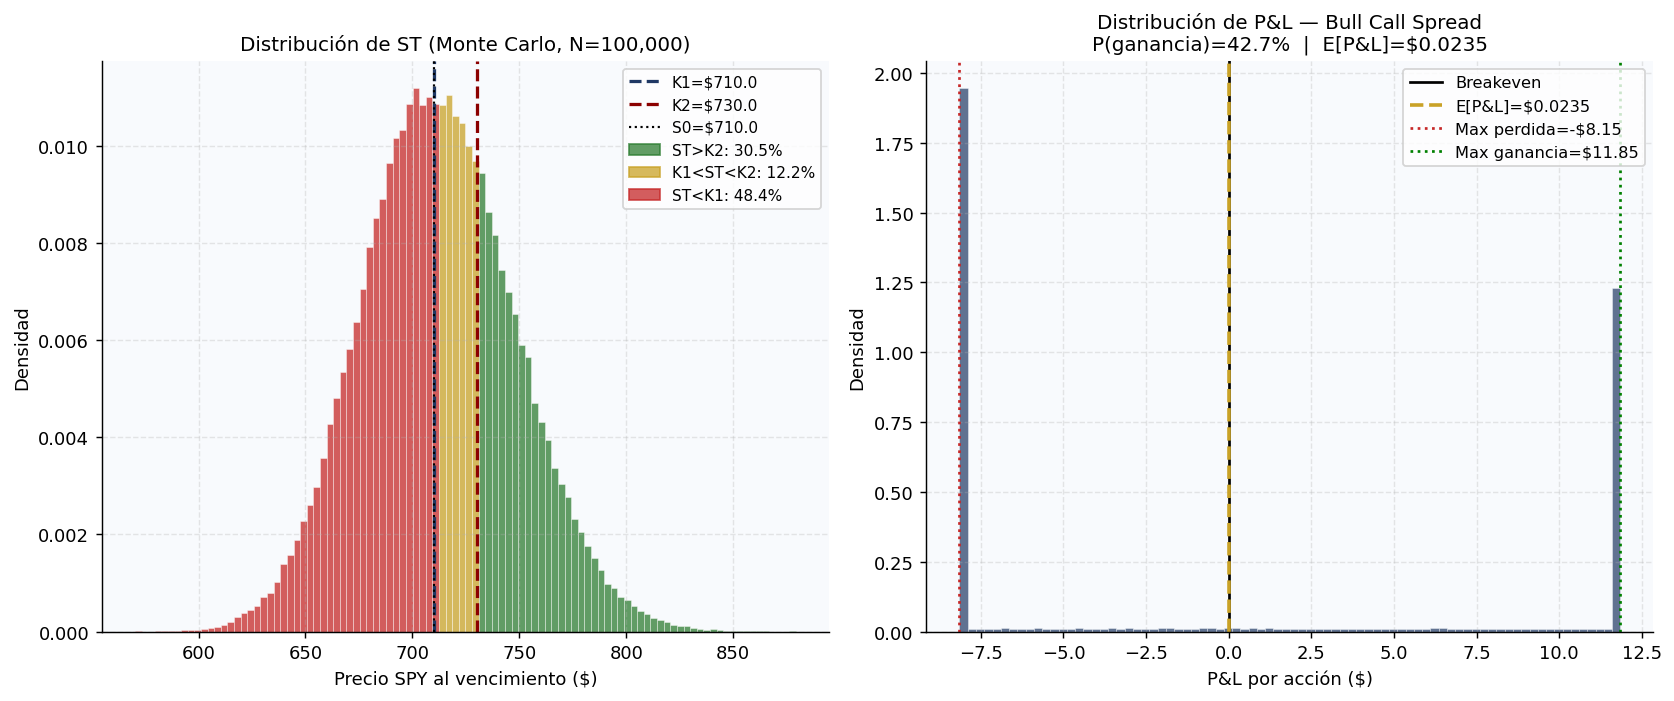

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('#F8FAFD')

#  Distribución de precios finales
ax1 = axes[0]
n, bins, patches = ax1.hist(ST_mc, bins=100, density=True,
                             edgecolor='white', linewidth=0.3, alpha=0.75)
for patch, b in zip(patches, bins[:-1]):
    if   b >= K2: patch.set_facecolor('#2E7D32')  # verde: ganancia max
    elif b >= K1: patch.set_facecolor('#C9A227')  # dorado: ganancia parcial
    else:         patch.set_facecolor('#C62828')  # rojo: pérdida

ax1.axvline(K1, color='#1F3864', lw=1.8, linestyle='--', label=f'K1=${K1}')
ax1.axvline(K2, color='darkred', lw=1.8, linestyle='--', label=f'K2=${K2}')
ax1.axvline(S0, color='black',   lw=1.2, linestyle=':',  label=f'S0=${S0}')

legend_patches = [
    mpatches.Patch(color='#2E7D32', alpha=0.75, label=f'ST>K2: {prob_max*100:.1f}%'),
    mpatches.Patch(color='#C9A227', alpha=0.75, label=f'K1<ST<K2: {(prob_profit-prob_max)*100:.1f}%'),
    mpatches.Patch(color='#C62828', alpha=0.75, label=f'ST<K1: {prob_loss*100:.1f}%'),
]
ax1.legend(handles=ax1.get_legend_handles_labels()[0] + legend_patches, fontsize=8.5)
ax1.set_xlabel('Precio SPY al vencimiento ($)', fontsize=10)
ax1.set_ylabel('Densidad', fontsize=10)
ax1.set_title(f'Distribución de ST (Monte Carlo, N={M:,})', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')

#  Distribución del P&L 
ax2 = axes[1]
ax2.hist(payoff_mc, bins=80, color='#1F3864', alpha=0.7,
         edgecolor='white', linewidth=0.3, density=True)
ax2.axvline(0,             color='black',   lw=1.5, linestyle='-',
            label='Breakeven')
ax2.axvline(expected_pnl,  color='#C9A227', lw=2,   linestyle='--',
            label=f'E[P&L]=${expected_pnl:.4f}')
ax2.axvline(-net_premium,  color='#C62828', lw=1.5, linestyle=':',
            label=f'Max perdida=-${net_premium:.2f}')
ax2.axvline(max_profit,    color='green',   lw=1.5, linestyle=':',
            label=f'Max ganancia=${max_profit:.2f}')
ax2.set_xlabel('P&L por acción ($)', fontsize=10)
ax2.set_ylabel('Densidad', fontsize=10)
ax2.set_title(f'Distribución de P&L — Bull Call Spread\n'
              f'P(ganancia)={prob_profit*100:.1f}%  |  E[P&L]=${expected_pnl:.4f}',
              fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## Gráfica 4: Trayectorias Monte Carlo

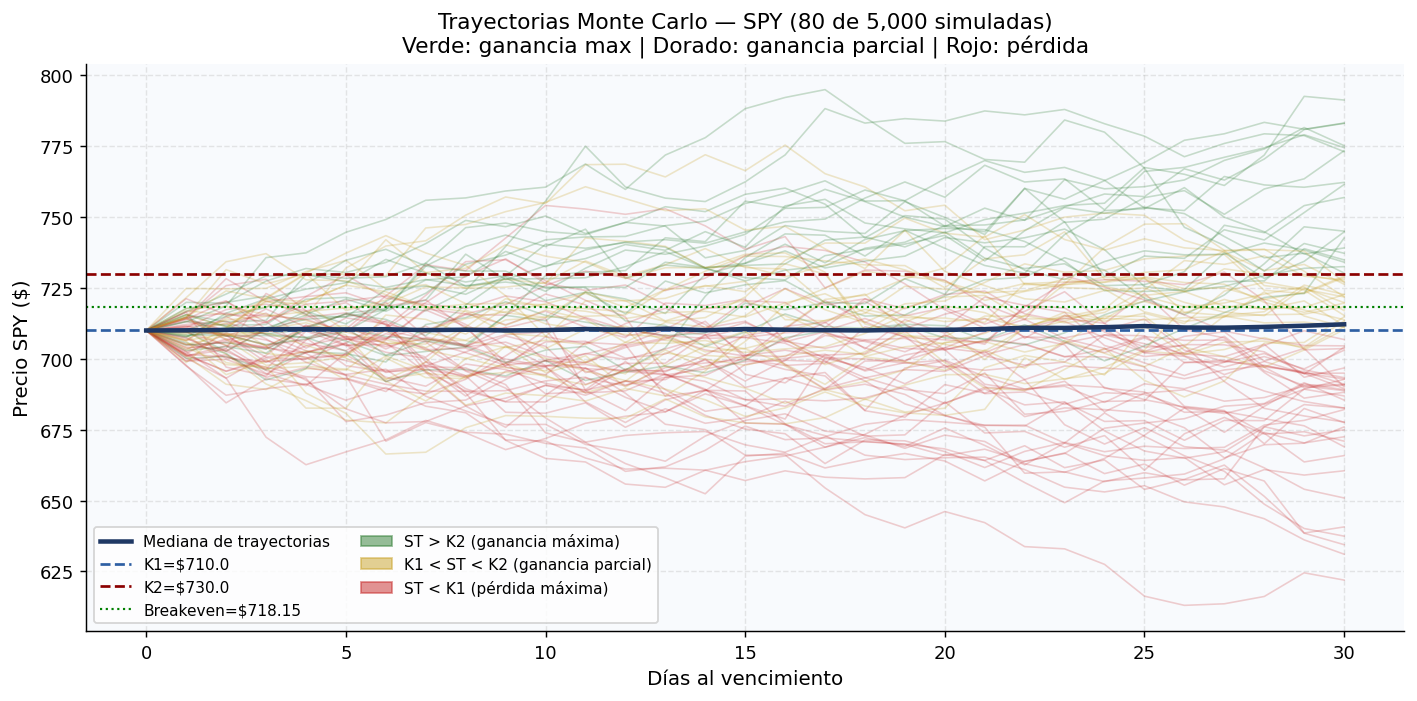

In [14]:
# Simular 5,000 trayectorias diarias (30 pasos)
steps    = 30
dt_daily = 1 / 365
n_paths  = 5000

Z_paths   = np.random.standard_normal((n_paths, steps))
daily_ret = (r - 0.5 * sigma**2) * dt_daily + sigma * np.sqrt(dt_daily) * Z_paths
S_paths   = S0 * np.exp(np.cumsum(daily_ret, axis=1))
S_paths   = np.hstack([np.full((n_paths, 1), S0), S_paths])

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.set_facecolor('#F8FAFD')

# Graficar 80 trayectorias de muestra
for i in range(80):
    final = S_paths[i, -1]
    if   final > K2: col, al = '#2E7D32', 0.25
    elif final > K1: col, al = '#C9A227', 0.25
    else:            col, al = '#C62828', 0.22
    ax.plot(range(steps + 1), S_paths[i], alpha=al, lw=0.9, color=col)

# Mediana
median_path = np.median(S_paths, axis=0)
ax.plot(range(steps + 1), median_path, color='#1F3864', lw=2.5,
        label='Mediana de trayectorias', zorder=5)

ax.axhline(K1,       color='#2E5FA3', lw=1.5, linestyle='--', label=f'K1=${K1}')
ax.axhline(K2,       color='darkred', lw=1.5, linestyle='--', label=f'K2=${K2}')
ax.axhline(breakeven,color='green',   lw=1.2, linestyle=':',  label=f'Breakeven=${breakeven:.2f}')

legend_patches = [
    mpatches.Patch(color='#2E7D32', alpha=0.5, label='ST > K2 (ganancia máxima)'),
    mpatches.Patch(color='#C9A227', alpha=0.5, label='K1 < ST < K2 (ganancia parcial)'),
    mpatches.Patch(color='#C62828', alpha=0.5, label='ST < K1 (pérdida máxima)'),
]
ax.legend(handles=ax.get_legend_handles_labels()[0] + legend_patches,
          fontsize=8.5, ncol=2)

ax.set_xlabel('Días al vencimiento', fontsize=11)
ax.set_ylabel('Precio SPY ($)', fontsize=11)
ax.set_title(f'Trayectorias Monte Carlo — SPY (80 de {n_paths:,} simuladas)\n'
             'Verde: ganancia max | Dorado: ganancia parcial | Rojo: pérdida', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Gráfica 5: Efecto Theta 

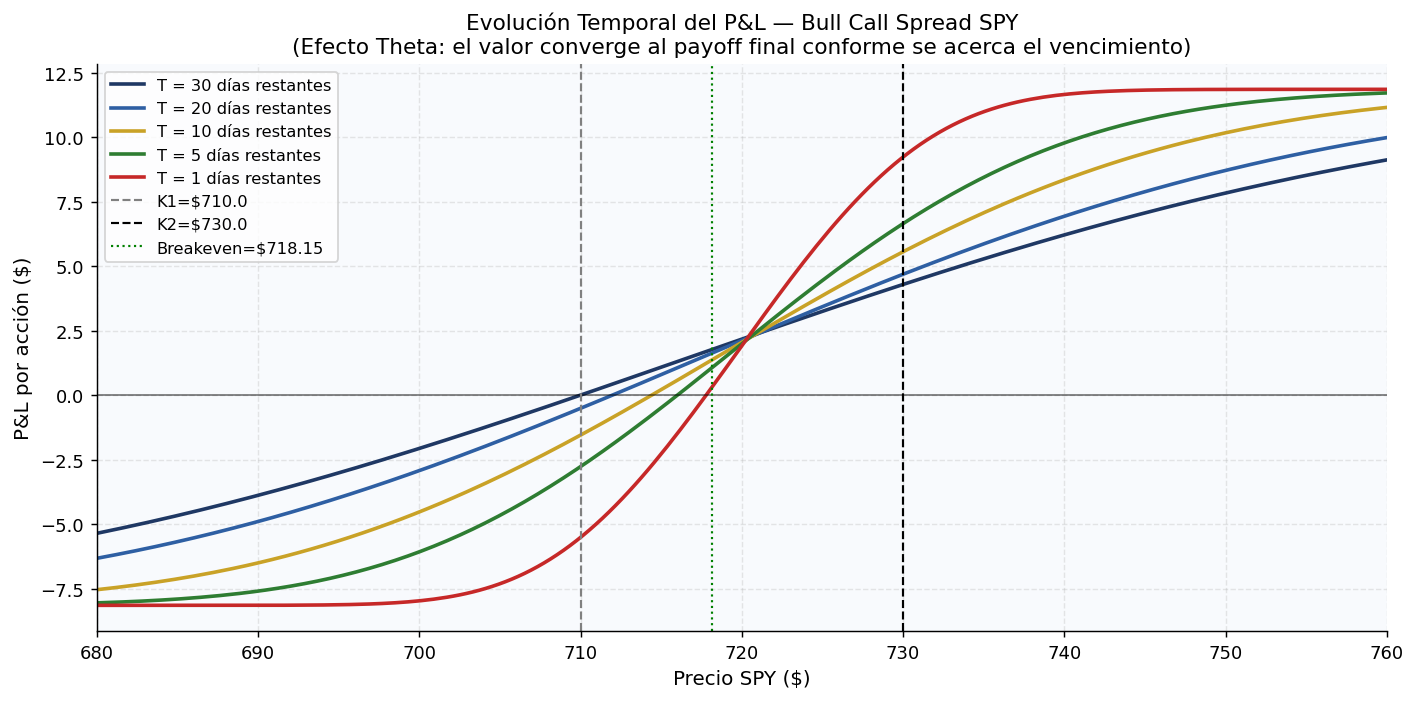

In [15]:
St_range = np.linspace(680, 760, 200)
days_list   = [30, 20, 10, 5, 1]
colors_list = ['#1F3864', '#2E5FA3', '#C9A227', '#2E7D32', '#C62828']

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.set_facecolor('#F8FAFD')

for days, col in zip(days_list, colors_list):
    t = days / 365
    pnl_t = np.array([bs_call(s,K1,r,sigma,t) - bs_call(s,K2,r,sigma,t) - net_premium
                      for s in St_range])
    ax.plot(St_range, pnl_t, color=col, lw=2, label=f'T = {days} días restantes')

ax.axhline(0,        color='black',   lw=1,   alpha=0.5)
ax.axvline(K1,       color='gray',    lw=1.2, linestyle='--', label=f'K1=${K1}')
ax.axvline(K2,       color='black',   lw=1.2, linestyle='--', label=f'K2=${K2}')
ax.axvline(breakeven,color='green',   lw=1.2, linestyle=':',  label=f'Breakeven=${breakeven:.2f}')

ax.set_xlabel('Precio SPY ($)', fontsize=11)
ax.set_ylabel('P&L por acción ($)', fontsize=11)
ax.set_title('Evolución Temporal del P&L — Bull Call Spread SPY\n'
             '(Efecto Theta: el valor converge al payoff final conforme se acerca el vencimiento)',
             fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(680, 760)
plt.tight_layout()
plt.show()

## Sección 12 — Resumen de resultados preliminares

In [16]:
summary = {
    'Métrica': [
        'Prima Long Call (K1=$710)',
        'Prima Short Call (K2=$730)',
        'Prima neta (débito)',
        'Ganancia máxima',
        'Pérdida máxima',
        'Punto de equilibrio',
        'Ratio riesgo/recompensa',
        '---',
        'Delta del spread',
        'Gamma del spread',
        'Theta del spread (diario)',
        'Vega del spread (+1% vol)',
        'Rho del spread (+1% tasa)',
        '---',
        'P(ganancia máxima) — ST>$730',
        'P(ganancia parcial) — $710<ST<$730',
        'P(pérdida máxima) — ST<$710',
        'E[P&L] Monte Carlo',
    ],
    'Valor': [
        f'${c1:.4f}',
        f'${c2:.4f}',
        f'${net_premium:.4f}',
        f'${max_profit:.4f}',
        f'${max_loss:.4f}',
        f'${breakeven:.4f}',
        f'{max_profit/max_loss:.2f}x',
        '---',
        f'{delta_spread:.4f}',
        f'{gamma_spread:.6f}',
        f'${theta_spread:.4f}/día',
        f'${vega_spread:.4f}',
        f'${rho_spread:.4f}',
        '---',
        f'{prob_max*100:.1f}%',
        f'{(prob_profit-prob_max)*100:.1f}%',
        f'{prob_loss*100:.1f}%',
        f'${expected_pnl:.4f}',
    ]
}

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))
print(f"\nModelo: Black-Scholes + Monte Carlo ({M:,} simulaciones)")
print(f"Parámetros: S0=${S0}, K1=${K1}, K2=${K2}, r={r*100:.2f}%, sigma={sigma*100:.1f}%, T=30d")

                           Métrica        Valor
         Prima Long Call (K1=$710)     $15.4569
        Prima Short Call (K2=$730)      $7.3095
               Prima neta (débito)      $8.1474
                   Ganancia máxima     $11.8526
                    Pérdida máxima      $8.1474
               Punto de equilibrio    $718.1474
           Ratio riesgo/recompensa        1.45x
                               ---          ---
                  Delta del spread       0.2146
                  Gamma del spread     0.001070
         Theta del spread (diario) $-0.0394/día
         Vega del spread (+1% vol)      $0.0776
         Rho del spread (+1% tasa)      $0.1185
                               ---          ---
      P(ganancia máxima) — ST>$730        30.5%
P(ganancia parcial) — $710<ST<$730        12.2%
       P(pérdida máxima) — ST<$710        48.4%
                E[P&L] Monte Carlo      $0.0235

Modelo: Black-Scholes + Monte Carlo (100,000 simulaciones)
Parámetros: S0=$710.0, K1=$7

---
## Referencias
- Hull, J. C. (2022). *Options, Futures, and Other Derivatives* (11th ed.). Pearson Education.
- Yahoo Finance. (2026). SPY Historical Data. https://finance.yahoo.com/quote/SPY/
- CBOE Global Markets. (2026). VIX Index. https://www.cboe.com/tradable_products/vix/
- The Budget Lab at Yale. (2026). State of U.S. Tariffs: April 8, 2026.